In [2]:
# Import Library
import pandas as pd
import numpy as np
from scipy.stats import zscore
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
## Import Excel
st = pd.read_csv("Sample - Superstore.csv", encoding="cp1252")

st

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200


In [3]:
st_copy = st.copy()

In [4]:
st_copy.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
st_copy.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

Data Supermarket merupakan data penjualan barang yang memiliki 9.994 Baris dan 21 Kolom, data superstore ini memiliki 15 string, 3 int dan 4 float64. tetapi ada beberapa data kolom yang perluh diubah tipe datanya seperti Order_date dan Ship_date menjadi tipe DATE.

## Missing Value

In [6]:
Missing = st_copy.isnull().sum()
print(f"Missing Value:")
print(Missing)

Missing Value:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


Mencari missing value pada data Superstore bisa menggunakan Pyton dan hasilnya tidak terdapat missing value di data Superstore yang membuat datanya siap untuk pemeriksaan selanjutnya.

## Duplikasi

In [7]:
## Duplicated 
SemuaData = st_copy.duplicated().sum()

#Buat jadi %
a = SemuaData / len(st_copy) * 100
print("=" * 50)
print(f"Duplikat: {SemuaData}")
print(f"Duplikat persen: {a:.2f}%")
print("=" * 50)

Duplikat: 0
Duplikat persen: 0.00%


Setelah itu, melanjutkan untuk mencari duplikasi dengan mengguanalan Pyton. Hasilnya tidak terdapat data yang duplikasi di data Superstore yang membuat data tersebut bisa lanjut untuk pengecekan selanjutnya.

## Outlier

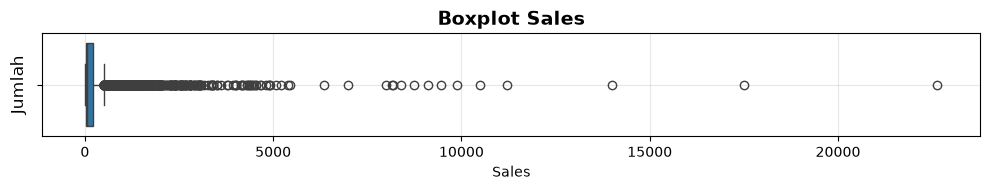

In [8]:
plt.figure(figsize=(10, 2)) 
sns.boxplot(x=st_copy["Sales"])
plt.title("Boxplot Sales", fontsize=14, fontweight="bold")
plt.ylabel("Jumlah", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

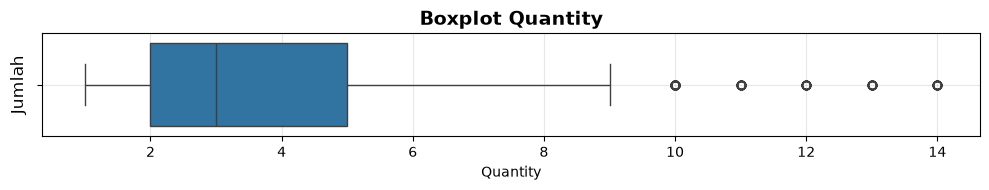

In [9]:
plt.figure(figsize=(10, 2)) 
sns.boxplot(x=st_copy["Quantity"])
plt.title("Boxplot Quantity", fontsize=14, fontweight="bold")
plt.ylabel("Jumlah", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

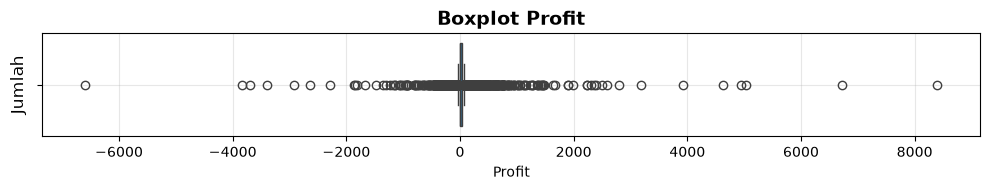

In [10]:
plt.figure(figsize=(10, 2)) 
sns.boxplot(x=st_copy["Profit"])
plt.title("Boxplot Profit", fontsize=14, fontweight="bold")
plt.ylabel("Jumlah", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Sales

In [11]:
stZSales = st_copy
stZSales["z_Score_Sales"] = zscore(stZSales["Sales"])
#Mencari Outlier dengan menghitung nilai absolut yang lebih besar dari 2
Outlier_Sales = stZSales[stZSales["z_Score_Sales"].abs()>2]
Outlier_Sales

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,z_Score_Sales
10,11,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.184,9,0.2,85.3092,2.368891
27,28,US-2015-150630,9/17/2015,9/21/2015,Standard Class,TB-21520,Tracy Blumstein,Consumer,United States,Philadelphia,...,East,FUR-BO-10004834,Furniture,Bookcases,"Riverside Palais Royal Lawyers Bookcase, Royal...",3083.430,7,0.5,-1665.0522,4.578800
149,150,CA-2016-114489,12/5/2016,12/9/2016,Standard Class,JE-16165,Justin Ellison,Corporate,United States,Franklin,...,Central,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",1951.840,8,0.0,585.5520,2.763067
165,166,CA-2014-139892,9/8/2014,9/12/2014,Standard Class,BM-11140,Becky Martin,Consumer,United States,San Antonio,...,Central,TEC-MA-10000822,Technology,Machines,Lexmark MX611dhe Monochrome Laser Printer,8159.952,8,0.4,-1359.9920,12.724514
167,168,CA-2014-139892,9/8/2014,9/12/2014,Standard Class,BM-11140,Becky Martin,Consumer,United States,San Antonio,...,Central,FUR-CH-10004287,Furniture,Chairs,SAFCO Arco Folding Chair,1740.060,9,0.3,-24.8580,2.423248
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9774,9775,CA-2014-169019,7/26/2014,7/30/2014,Standard Class,LF-17185,Luke Foster,Consumer,United States,San Antonio,...,Central,OFF-BI-10004995,Office Supplies,Binders,GBC DocuBind P400 Electric Binding System,2177.584,8,0.8,-3701.8928,3.125293
9857,9858,CA-2015-164301,3/26/2015,3/30/2015,Standard Class,EB-13840,Ellis Ballard,Corporate,United States,Seattle,...,West,FUR-TA-10001889,Furniture,Tables,Bush Advantage Collection Racetrack Conference...,3393.680,8,0.0,610.8624,5.076623
9929,9930,CA-2016-129630,9/4/2016,9/4/2016,Same Day,IM-15055,Ionia McGrath,Consumer,United States,San Francisco,...,West,TEC-CO-10003763,Technology,Copiers,Canon PC1060 Personal Laser Copier,2799.960,5,0.2,944.9865,4.123948
9947,9948,CA-2017-121559,6/1/2017,6/3/2017,Second Class,HW-14935,Helen Wasserman,Corporate,United States,Indianapolis,...,Central,FUR-CH-10003746,Furniture,Chairs,Hon 4070 Series Pagoda Round Back Stacking Chairs,1925.880,6,0.0,539.2464,2.721412


In [12]:
ZSales = (stZSales["z_Score_Sales"].abs()>2).sum()
#Buat jadi %
a = ZSales / len(st_copy) * 100

print("=" * 50)
print("Jumlah Outlier Sales")
print(f"Outlier Profit: {ZSales}")
print(f"Outlier Profit persen: {a:.2f}%")
#Menghitung Outlier per Category
print("=" * 50)
outlier_per_category = stZSales[stZSales["z_Score_Sales"].abs() > 2].groupby("Category")["z_Score_Sales"].count()
print("Jumlah Outlier Sales per Category:")
print(outlier_per_category)
print("=" * 50)

Jumlah Outlier Sales
Outlier Profit: 247
Outlier Profit persen: 2.47%
Jumlah Outlier Sales per Category:
Category
Furniture          83
Office Supplies    65
Technology         99
Name: z_Score_Sales, dtype: int64


## Quantity

In [13]:
stZQuantity = st_copy
stZQuantity["z_Score_Quantity"] = zscore(stZQuantity["Quantity"])
Outlier_Quantity = stZQuantity[stZQuantity["z_Score_Quantity"].abs()>2]
Outlier_Quantity

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,z_Score_Sales,z_Score_Quantity
10,11,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.184,9,0.2,85.3092,2.368891,2.341766
37,38,CA-2015-117415,12/27/2015,12/31/2015,Standard Class,SN-20710,Steve Nguyen,Home Office,United States,Houston,...,OFF-EN-10002986,Office Supplies,Envelopes,"#10-4 1/8"" x 9 1/2"" Premium Diagonal Seam Enve...",113.328,9,0.2,35.4150,-0.186982,2.341766
113,114,CA-2014-115259,8/25/2014,8/27/2014,Second Class,RC-19960,Ryan Crowe,Consumer,United States,Columbus,...,OFF-FA-10000621,Office Supplies,Fasteners,"OIC Colored Binder Clips, Assorted Sizes",40.096,14,0.2,14.5348,-0.304489,4.588959
122,123,CA-2016-103730,6/12/2016,6/15/2016,First Class,SC-20725,Steven Cartwright,Consumer,United States,Wilmington,...,OFF-EN-10002500,Office Supplies,Envelopes,Globe Weis Peel & Seel First Class Envelopes,115.020,9,0.0,51.7590,-0.184267,2.341766
132,133,US-2017-164147,2/2/2017,2/5/2017,First Class,DW-13585,Dorothy Wardle,Corporate,United States,Columbus,...,OFF-FA-10002780,Office Supplies,Fasteners,Staples,21.456,9,0.2,6.9732,-0.334399,2.341766
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9895,9896,CA-2014-115049,9/26/2014,10/1/2014,Standard Class,MM-17920,Michael Moore,Consumer,United States,Chicago,...,TEC-AC-10004859,Technology,Accessories,"Maxell Pro 80 Minute CD-R, 10/Pack",153.824,11,0.2,38.4560,-0.122003,3.240643
9941,9942,CA-2017-164028,11/24/2017,11/30/2017,Standard Class,JL-15835,John Lee,Consumer,United States,San Francisco,...,TEC-AC-10001772,Technology,Accessories,Memorex Mini Travel Drive 16 GB USB 2.0 Flash ...,223.580,14,0.0,87.1962,-0.010074,4.588959
9942,9943,CA-2014-143371,12/28/2014,1/3/2015,Standard Class,MD-17350,Maribeth Dona,Consumer,United States,Anaheim,...,OFF-ST-10001128,Office Supplies,Storage,"Carina Mini System Audio Rack, Model AR050B",998.820,9,0.0,29.9646,1.233865,2.341766
9979,9980,US-2016-103674,12/6/2016,12/10/2016,Standard Class,AP-10720,Anne Pryor,Home Office,United States,Los Angeles,...,OFF-BI-10002026,Office Supplies,Binders,Ibico Recycled Linen-Style Covers,437.472,14,0.2,153.1152,0.333134,4.588959


In [14]:
'''
Setelah mencari Outleir, saya menghitung Total Outleir yang ditemukan dan menghitung Outleir Quantity per Category
'''
ZQuantity = (stZQuantity["z_Score_Quantity"].abs()>2).sum()
#Buat jadi %
a = ZQuantity / len(st_copy) * 100
print(f"Outlier Quantity: {ZQuantity}")
print(f"Outlier Quantity persen: {a:.2f}%")
#Menghitung Outlier per Category
print("=" * 50)
Outlier_Quantity_per_Category = stZQuantity[stZQuantity["z_Score_Quantity"].abs() > 2].groupby("Category")["z_Score_Quantity"].count()
print("Jumlah Outlier Quantity per Category:")
print(Outlier_Quantity_per_Category)
print("=" * 50)

Outlier Quantity: 428
Outlier Quantity persen: 4.28%
Jumlah Outlier Quantity per Category:
Category
Furniture           97
Office Supplies    254
Technology          77
Name: z_Score_Quantity, dtype: int64


## Discount

In [15]:
'''
Saya menggunakan zscore pada Kolom Profit untuk mencari Outlier dengan mencari dengan membuat kolom baru dan mencari 
nilai yang lebih atau kurang dari 2
'''
stZDiscount = st_copy
stZDiscount["z_Score_Discount"] = zscore(stZDiscount["Discount"])
Outlier_Discount = stZDiscount[stZDiscount["z_Score_Discount"].abs()>2]
Outlier_Discount

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,z_Score_Sales,z_Score_Quantity,z_Score_Discount
14,15,US-2015-118983,11/22/2015,11/26/2015,Standard Class,HP-14815,Harold Pawlan,Home Office,United States,Fort Worth,...,Office Supplies,Appliances,Holmes Replacement Filter for HEPA Air Cleaner...,68.810,5,0.8,-123.8580,-0.258415,0.544012,3.118544
15,16,US-2015-118983,11/22/2015,11/26/2015,Standard Class,HP-14815,Harold Pawlan,Home Office,United States,Fort Worth,...,Office Supplies,Binders,Storex DuraTech Recycled Plastic Frosted Binders,2.544,3,0.8,-3.8160,-0.364745,-0.354865,3.118544
28,29,US-2015-150630,9/17/2015,9/21/2015,Standard Class,TB-21520,Tracy Blumstein,Consumer,United States,Philadelphia,...,Office Supplies,Binders,Avery Recycled Flexi-View Covers for Binding S...,9.618,2,0.7,-7.0532,-0.353394,-0.804303,2.634145
32,33,US-2015-150630,9/17/2015,9/21/2015,Standard Class,TB-21520,Tracy Blumstein,Consumer,United States,Philadelphia,...,Office Supplies,Binders,"Acco Pressboard Covers with Storage Hooks, 14 ...",6.858,6,0.7,-5.7150,-0.357823,0.993451,2.634145
36,37,CA-2016-117590,12/8/2016,12/10/2016,First Class,GH-14485,Gene Hale,Corporate,United States,Richardson,...,Furniture,Furnishings,"Electrix Architect's Clamp-On Swing Arm Lamp, ...",190.920,5,0.6,-147.9630,-0.062479,0.544012,2.149747
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9870,9871,CA-2014-114195,11/1/2014,11/3/2014,First Class,EA-14035,Erin Ashbrook,Corporate,United States,Mason,...,Office Supplies,Binders,GBC Standard Therm-A-Bind Covers,22.428,3,0.7,-17.9424,-0.332839,-0.354865,2.634145
9877,9878,US-2017-166324,4/20/2017,4/21/2017,First Class,BE-11455,Brad Eason,Home Office,United States,Cleveland,...,Office Supplies,Binders,Wilson Jones Clip & Carry Folder Binder Tool f...,8.700,5,0.7,-6.3800,-0.354867,0.544012,2.634145
9903,9904,CA-2014-122609,11/12/2014,11/18/2014,Standard Class,DP-13000,Darren Powers,Consumer,United States,Carrollton,...,Furniture,Furnishings,"GE General Use Halogen Bulbs, 100 Watts, 1 Bul...",25.128,3,0.6,-6.9102,-0.328507,-0.354865,2.149747
9920,9921,CA-2016-149272,3/15/2016,3/19/2016,Standard Class,MY-18295,Muhammed Yedwab,Corporate,United States,Bryan,...,Office Supplies,Binders,"GBC Pre-Punched Binding Paper, Plastic, White,...",22.386,7,0.8,-35.8176,-0.332907,1.442889,3.118544


In [16]:
'''
Setelah mencari Outleir, saya menghitung Total Outleir yang ditemukan dan menghitung Outleir Quantity per Category
'''
ZDiscount = (stZDiscount["z_Score_Discount"].abs()>2).sum()
#Buat jadi %
a = ZDiscount / len(st_copy) * 100
print(f"Outlier Discount: {ZDiscount}")
print(f"Outlier Discount persen: {a:.2f}%")
#Menghitung Outlier per Category
print("=" * 50)
Outlier_Discount_per_Category = stZQuantity[stZDiscount["z_Score_Discount"].abs() > 2].groupby("Category")["z_Score_Discount"].count()
print("Jumlah Outlier Discount per Category:")
print(Outlier_Discount_per_Category)
print("=" * 50)

Outlier Discount: 856
Outlier Discount persen: 8.57%
Jumlah Outlier Discount per Category:
Category
Furniture          153
Office Supplies    680
Technology          23
Name: z_Score_Discount, dtype: int64


In [17]:
'''
Saya menggunakan zscore pada Kolom Profit untuk mencari Outlier dengan mencari dengan membuat kolom baru dan mencari 
nilai yang lebih atau kurang dari 2
'''
stZProfit = st_copy
stZProfit["z_Score_Profit"] = zscore(stZProfit["Profit"])
Outlier_Profit = stZProfit[stZProfit["z_Score_Profit"].abs()>2]
Outlier_Profit

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,z_Score_Sales,z_Score_Quantity,z_Score_Discount,z_Score_Profit
27,28,US-2015-150630,9/17/2015,9/21/2015,Standard Class,TB-21520,Tracy Blumstein,Consumer,United States,Philadelphia,...,Bookcases,"Riverside Palais Royal Lawyers Bookcase, Royal...",3083.430,7,0.5,-1665.0522,4.578800,1.442889,1.665349,-7.230398
149,150,CA-2016-114489,12/5/2016,12/9/2016,Standard Class,JE-16165,Justin Ellison,Corporate,United States,Franklin,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",1951.840,8,0.0,585.5520,2.763067,1.892328,-0.756643,2.377370
165,166,CA-2014-139892,9/8/2014,9/12/2014,Standard Class,BM-11140,Becky Martin,Consumer,United States,San Antonio,...,Machines,Lexmark MX611dhe Monochrome Laser Printer,8159.952,8,0.4,-1359.9920,12.724514,1.892328,1.180950,-5.928104
169,170,CA-2014-139892,9/8/2014,9/12/2014,Standard Class,BM-11140,Becky Martin,Consumer,United States,San Antonio,...,Appliances,Kensington 7 Outlet MasterPiece Power Center,177.980,5,0.8,-453.8490,-0.083243,0.544012,3.118544,-2.059805
215,216,CA-2015-146262,1/2/2015,1/9/2015,Standard Class,VW-21775,Victoria Wilson,Corporate,United States,Medina,...,Machines,Cisco 9971 IP Video Phone Charcoal,1188.000,9,0.7,-950.4000,1.537421,2.341766,2.634145,-4.179567
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9774,9775,CA-2014-169019,7/26/2014,7/30/2014,Standard Class,LF-17185,Luke Foster,Consumer,United States,San Antonio,...,Binders,GBC DocuBind P400 Electric Binding System,2177.584,8,0.8,-3701.8928,3.125293,1.892328,3.118544,-15.925615
9857,9858,CA-2015-164301,3/26/2015,3/30/2015,Standard Class,EB-13840,Ellis Ballard,Corporate,United States,Seattle,...,Tables,Bush Advantage Collection Racetrack Conference...,3393.680,8,0.0,610.8624,5.076623,1.892328,-0.756643,2.485419
9929,9930,CA-2016-129630,9/4/2016,9/4/2016,Same Day,IM-15055,Ionia McGrath,Consumer,United States,San Francisco,...,Copiers,Canon PC1060 Personal Laser Copier,2799.960,5,0.2,944.9865,4.123948,0.544012,0.212153,3.911786
9947,9948,CA-2017-121559,6/1/2017,6/3/2017,Second Class,HW-14935,Helen Wasserman,Corporate,United States,Indianapolis,...,Chairs,Hon 4070 Series Pagoda Round Back Stacking Chairs,1925.880,6,0.0,539.2464,2.721412,0.993451,-0.756643,2.179693


In [18]:
'''
Setelah mencari Outleir, saya menghitung Total Outleir yang ditemukan dan menghitung Outleir Profit per Category
'''
ZProfit = (stZProfit["z_Score_Profit"].abs()>2).sum()
#Buat jadi %
a = ZProfit / len(st_copy) * 100
print("=" * 50)
print(f"Outlier Profit: {ZProfit}")
print(f"Outlier Profit persen: {a:.2f}%")
#Menghitung Outlier per Category
print("=" * 50)
Outlier_Profit_per_Category = stZProfit[stZProfit["z_Score_Profit"].abs() > 2].groupby("Category")["z_Score_Profit"].count()
print("Jumlah Outlier Profit per Category:")
print(Outlier_Profit_per_Category)
print("=" * 50)

Outlier Profit: 179
Outlier Profit persen: 1.79%
Jumlah Outlier Profit per Category:
Category
Furniture          33
Office Supplies    65
Technology         81
Name: z_Score_Profit, dtype: int64


Lanjut untuk mecari outlier bisa menggunakan Pyton dan hasilnya ada terdapat data yang outlier, solusinya adalah membiarkanya karena itu adalah data penjualan.

======================================================================

## EDA

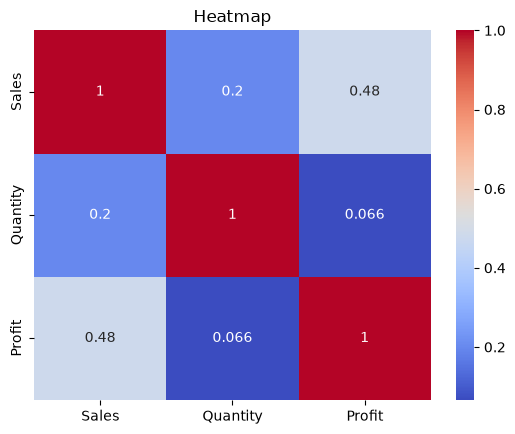

In [19]:
corr = st_copy[["Sales", "Quantity", "Profit"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Heatmap")
plt.show()

## Kesimpulan

Kesimpulan dari data yang sudah dicleaning bahwa tidak terdapat Missing value, tidak terdapat duplicate, tetapi terdapat data outlier dalam data superstore tersebut. cara mengatasinya yaitu dengan membiarkannya dikarenakan data superstore merupakan data penjualan.

In [20]:
'''Export df_copy menjadi excel'''
st_copy.to_excel("Sample - Superstore Bersih.xlsx")